In [1]:
import pandas as pd

In [2]:
df=pd.read_csv('dfsubst_her2.csv')

In [3]:
df.head(3)

,Unnamed: 0,molecule_chembl_id,canonical_smiles,standard_value,units,activity,Name,SubFP1,SubFP2,SubFP3,...,SubFP298,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307
0,0,CHEMBL68920,Cc1cc(C)c(/C=C2\C(=O)Nc3ncnc(Nc4ccc(F)c(Cl)c4)...,300.0,uM,0,AUTOGEN_molecule_1,1,0,0,...,0,0,1,1,1,1,0,0,0,1
1,1,CHEMBL69960,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,400.0,uM,0,AUTOGEN_molecule_2,1,0,0,...,0,0,1,1,1,1,0,0,0,1
2,2,CHEMBL67057,Cc1cc(C(=O)N2CCOCC2)[nH]c1/C=C1\C(=O)Nc2ncnc(N...,100.0,uM,0,AUTOGEN_molecule_3,1,0,0,...,0,0,1,1,1,1,0,0,0,1


In [4]:
df1= df.drop(['molecule_chembl_id','Unnamed: 0','canonical_smiles','standard_value', 'Name','units' ], axis=1)

In [5]:
df1.head(3)

,activity,SubFP1,SubFP2,SubFP3,SubFP4,SubFP5,SubFP6,SubFP7,SubFP8,SubFP9,...,SubFP298,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307
0,0,1,0,0,0,1,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1
1,0,1,0,0,0,1,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1
2,0,1,0,0,0,1,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1


Model Generation

In [6]:
X= df1.drop('activity', axis=1)
X.head(3)

,SubFP1,SubFP2,SubFP3,SubFP4,SubFP5,SubFP6,SubFP7,SubFP8,SubFP9,SubFP10,...,SubFP298,SubFP299,SubFP300,SubFP301,SubFP302,SubFP303,SubFP304,SubFP305,SubFP306,SubFP307
0,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1
1,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1
2,1,0,0,0,1,0,0,0,0,0,...,0,0,1,1,1,1,0,0,0,1


In [7]:
y=df1.activity
y.head(3)

,activity
0,0
1,0
2,0


Model Preparation

In [8]:
from sklearn.model_selection import train_test_split
#X_train,X_test,y_train,y_test = train_test_split(X,y,train_size=0.80,random_state=0)
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=0)

Preprocessing standard Scalar

In [9]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.fit_transform(X_test)

Random forest

In [10]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=100, criterion='gini',random_state=25)
rfc.fit(X_train,y_train)
y_pred = rfc.predict(X_test)

Compare the result

In [11]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score,ConfusionMatrixDisplay,precision_score,recall_score,f1_score, roc_curve, roc_auc_score
import matplotlib.pyplot as plt

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.81      0.91      0.86       145
           1       0.90      0.80      0.85       152

    accuracy                           0.85       297
   macro avg       0.86      0.85      0.85       297
weighted avg       0.86      0.85      0.85       297



Accuracy matrix

In [12]:
confusion_matrix(y_test,y_pred)

array([[132,  13],
       [ 31, 121]])

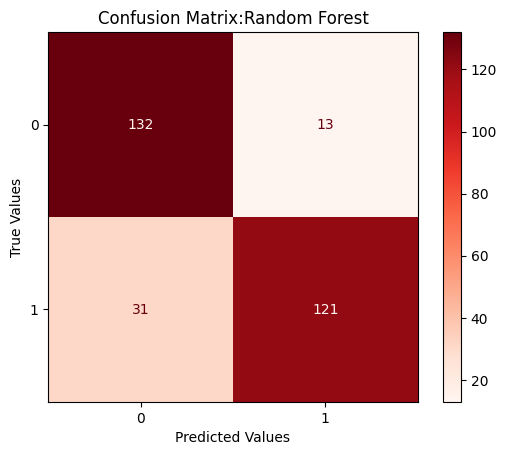

In [13]:

cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:Random Forest')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


ROC

In [14]:
rrf_probs = [0 for _ in range(len(y_test))]
rfrf_probs = rfc.predict_proba(X_test)

rfrf_probs = rfrf_probs[:, 1]

rfrf_auc = roc_auc_score(y_test, rfrf_probs)
print('Random Forest: AUC_ROC = %.3f' % (rfrf_auc))

Random Forest: AUC_ROC = 0.931


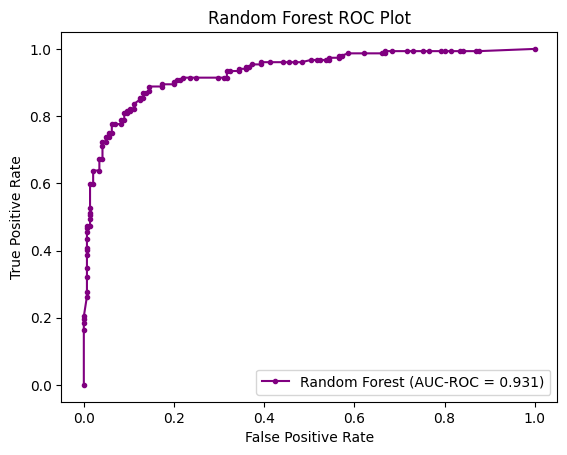

In [15]:
rfrf_fpr, rfrf_tpr, _ = roc_curve(y_test, rfrf_probs)

plt.plot(rfrf_fpr, rfrf_tpr, marker='.', label='Random Forest (AUC-ROC = %0.3f)' % rfrf_auc, color='purple')
# Title
plt.title('Random Forest ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('Random Forest ROC Plot')

# Show plot
plt.show()


XGBoost

In [16]:
from xgboost import XGBClassifier

In [17]:
xgb = XGBClassifier(random_state=0)
xgb.fit(X_train,y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=0, ...)

In [18]:
y_pred=xgb.predict(X_test)

In [19]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.25      0.01      0.01       145
           1       0.51      0.98      0.67       152

    accuracy                           0.51       297
   macro avg       0.38      0.49      0.34       297
weighted avg       0.38      0.51      0.35       297



In [20]:
confusion_matrix(y_test,y_pred)

array([[  1, 144],
       [  3, 149]])

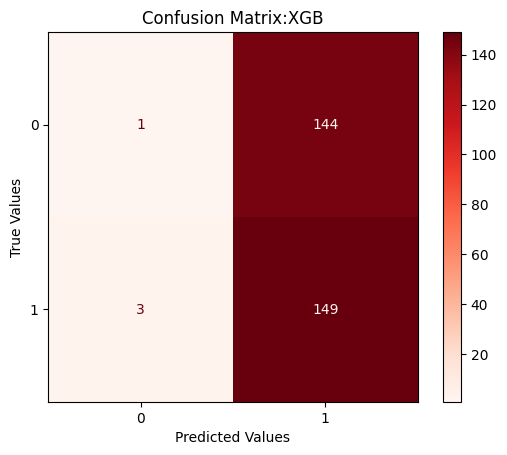

In [21]:
cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:XGB')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


ROC

In [22]:
rxgb_probs = [0 for _ in range(len(y_test))]
rfxgb_probs = xgb.predict_proba(X_test)

rfxgb_probs = rfxgb_probs[:, 1]

rfxgb_auc = roc_auc_score(y_test, rfxgb_probs)
print('XGBoost: AUC_ROC = %.3f' % (rfxgb_auc))


XGBoost: AUC_ROC = 0.477


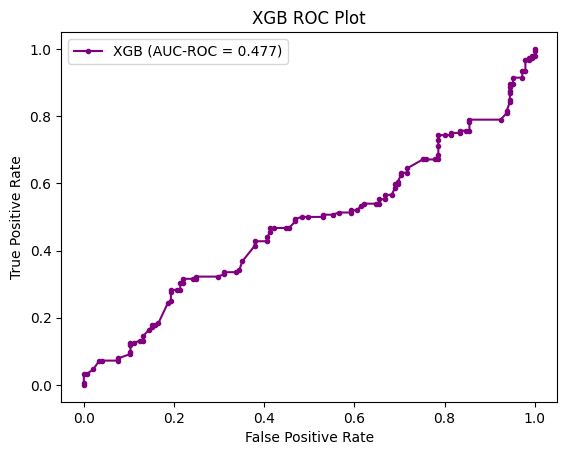

In [23]:
rfxgb_fpr, rfxgb_tpr, _ = roc_curve(y_test, rfxgb_probs)

plt.plot(rfxgb_fpr, rfxgb_tpr, marker='.', label='XGB (AUC-ROC = %0.3f)' % rfxgb_auc, color='purple')
# Title
plt.title('XGB ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('XGBoost ROC Plot')

# Show plot
plt.show()


KNN

In [24]:
from sklearn.neighbors import KNeighborsClassifier
knn5 = KNeighborsClassifier(n_neighbors=5)
knn5.fit(X_train,y_train)

KNeighborsClassifier()

In [25]:
y_pred = knn5.predict(X_test)
accuracy_score(y_pred,y_test)

0.8114478114478114

In [26]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.87      0.82       145
           1       0.86      0.76      0.80       152

    accuracy                           0.81       297
   macro avg       0.82      0.81      0.81       297
weighted avg       0.82      0.81      0.81       297



In [27]:
confusion_matrix(y_test,y_pred)

array([[126,  19],
       [ 37, 115]])

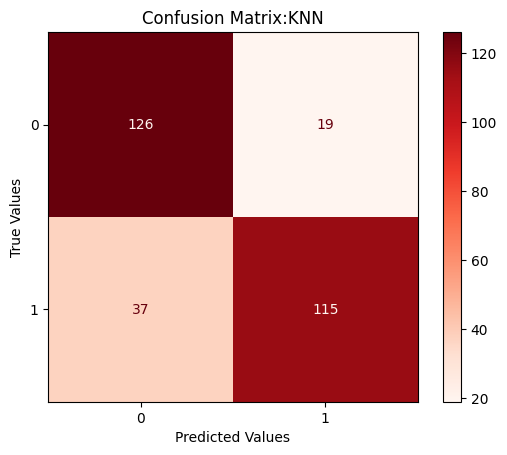

In [28]:
cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:KNN')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


ROC

In [29]:
rknn_probs = [0 for _ in range(len(y_test))]
rfknn_probs = knn5.predict_proba(X_test)

rfknn_probs = rfknn_probs[:, 1]

rfknn_auc = roc_auc_score(y_test, rfknn_probs)
print('KNN: AUC_ROC = %.3f' % (rfknn_auc))


KNN: AUC_ROC = 0.871


In [30]:
rfknn_fpr, rfknn_tpr,_ = roc_curve(y_test, rfknn_probs)

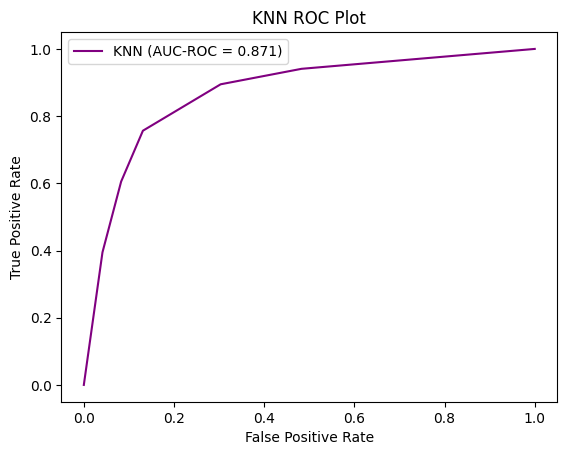

In [31]:
rfknn_fpr, rfknn_tpr,_ = roc_curve(y_test, rfknn_probs)

plt.plot(rfknn_fpr, rfknn_tpr, label='KNN (AUC-ROC = %0.3f)' % rfknn_auc, color='purple')
# Title
plt.title('KNN ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('KNN ROC Plot')

# Show plot
plt.show()


Logistic regression

In [32]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(X_train, y_train)

LogisticRegression()

In [33]:
y_pred=lr.predict(X_test)

In [34]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.79      0.83      0.81       145
           1       0.83      0.78      0.81       152

    accuracy                           0.81       297
   macro avg       0.81      0.81      0.81       297
weighted avg       0.81      0.81      0.81       297



In [35]:
confusion_matrix(y_test,y_pred)

array([[121,  24],
       [ 33, 119]])

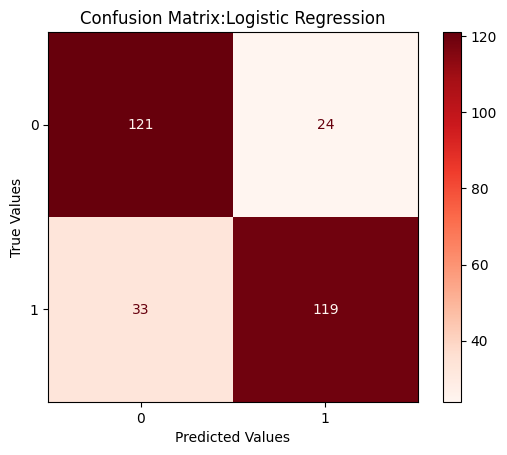

In [36]:
cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:Logistic Regression')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


In [37]:
rlr_probs = [0 for _ in range(len(y_test))]
rflr_probs = lr.predict_proba(X_test)

rflr_probs = rflr_probs[:, 1]

rflr_auc = roc_auc_score(y_test, rflr_probs)
print('Logistic Regression: AUC_ROC = %.3f' % (rflr_auc))


Logistic Regression: AUC_ROC = 0.872


In [38]:
rflr_fpr, rflr_tpr, _ = roc_curve(y_test, rflr_probs)

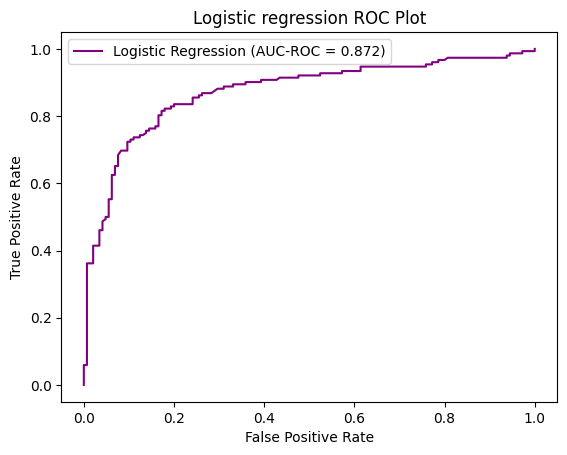

In [39]:
rflr_fpr, rflr_tpr, _ = roc_curve(y_test, rflr_probs)

plt.plot(rflr_fpr, rflr_tpr, label='Logistic Regression (AUC-ROC = %0.3f)' % rflr_auc, color='purple')
# Title
plt.title('Logistic regression ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('Logistic Regression ROC Plot')

# Show plot
plt.show()


Desicion Tree

In [40]:
from sklearn.tree import DecisionTreeClassifier
dtr = DecisionTreeClassifier(criterion = 'gini', random_state = 1)

In [41]:
dtr.fit(X_train, y_train)
y_pred=dtr.predict(X_test)

In [42]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.78      0.90      0.84       145
           1       0.89      0.76      0.82       152

    accuracy                           0.83       297
   macro avg       0.83      0.83      0.83       297
weighted avg       0.84      0.83      0.83       297



In [43]:
confusion_matrix(y_test,y_pred)


array([[130,  15],
       [ 36, 116]])

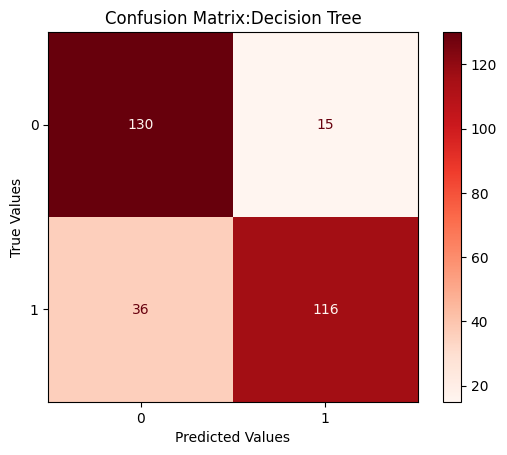

In [44]:
cm= confusion_matrix(y_test,y_pred)

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Reds)
plt.title('Confusion Matrix:Decision Tree')
plt.xlabel('Predicted Values')
plt.ylabel('True Values')
plt.show()


In [45]:
rdt_probs = [0 for _ in range(len(y_test))]
rfdt_probs = dtr.predict_proba(X_test)

rfdt_probs = rfdt_probs[:, 1]

rfdt_auc = roc_auc_score(y_test, rfdt_probs)
print('Decision Tree: AUC_ROC = %.3f' % (rfdt_auc))


Decision Tree: AUC_ROC = 0.853


In [46]:
rfdt_fpr, rfdt_tpr, _ = roc_curve(y_test, rfdt_probs)

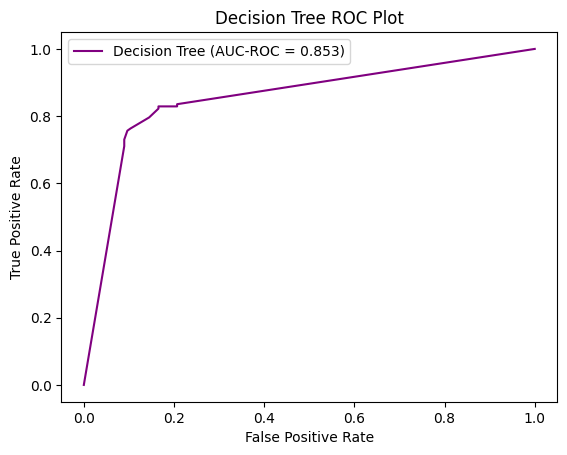

In [47]:
rfdt_fpr, rfdt_tpr, _ = roc_curve(y_test, rfdt_probs)

plt.plot(rfdt_fpr, rfdt_tpr, label='Decision Tree (AUC-ROC = %0.3f)' % rfdt_auc, color='purple')
# Title
plt.title('Decision Tree ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('Decision Tree ROC Plot')

# Show plot
plt.show()



ANN

In [48]:
import tensorflow as tf
from sklearn.model_selection import train_test_split
from keras.models import Sequential
from keras.layers import Dense
from keras.models import Sequential

In [49]:
model = Sequential()

model.add(Dense(12, input_dim=307, activation='relu'))

model.add(Dense(6, activation='relu'))

model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

/usr/local/lib/python3.10/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.fit(X_train, y_train, epochs=200, batch_size=10)

Epoch 1/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.5599 - loss: 0.6735
Epoch 2/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7975 - loss: 0.5221
Epoch 3/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8052 - loss: 0.4608
Epoch 4/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8540 - loss: 0.3872
Epoch 5/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8473 - loss: 0.3696
Epoch 6/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8526 - loss: 0.3474
Epoch 7/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8539 - loss: 0.3443
Epoch 8/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8653 - loss: 0.3132
Epoch 9/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8640 - loss: 0.3245
Epoch 10/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8511 - loss: 0.3476
Epoch 11/200
119/119 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8748 - loss: 0.2938
Epoch 12/200
119/119 ━━━━━━━━━━━━━━━━━━━━

In [51]:
y_pred = model.predict(X_test).round()

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


In [52]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[124,  21],
       [ 24, 128]])

In [53]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.84      0.86      0.85       145
           1       0.86      0.84      0.85       152

    accuracy                           0.85       297
   macro avg       0.85      0.85      0.85       297
weighted avg       0.85      0.85      0.85       297



In [54]:
rfann_auc = roc_auc_score(y_test, y_pred)
print('NN: AUC_ROC = %.3f' % (rfann_auc))

NN: AUC_ROC = 0.849


In [55]:
rfann_fpr, rfann_tpr, _ = roc_curve(y_test, y_pred)

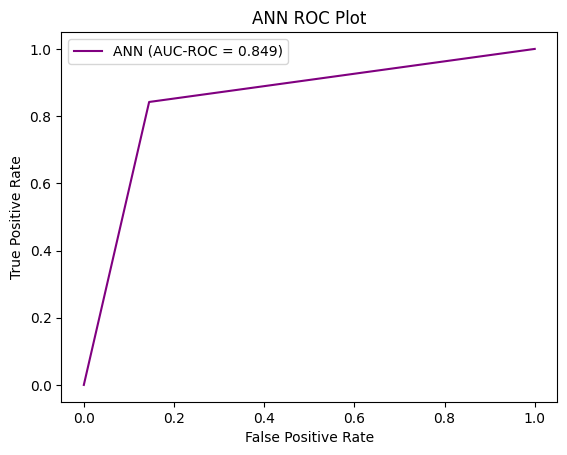

In [56]:
rfann_fpr, rfann_tpr, _ = roc_curve(y_test, y_pred)

plt.plot(rfann_fpr, rfann_tpr, label='ANN (AUC-ROC = %0.3f)' % rfann_auc, color='purple')
# Title
plt.title('ANN ROC Plot')
# Axis labels
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
# Show legend
plt.legend() #

plt.savefig('ANN ROC Plot')

# Show plot
plt.show()

In [57]:
# roc curve for tpr = fpr
random_probs = [0 for i in range(len(y_test))]
p_fpr, p_tpr, _ = roc_curve(y_test, random_probs, pos_label=1)

All ROC plots Combined.

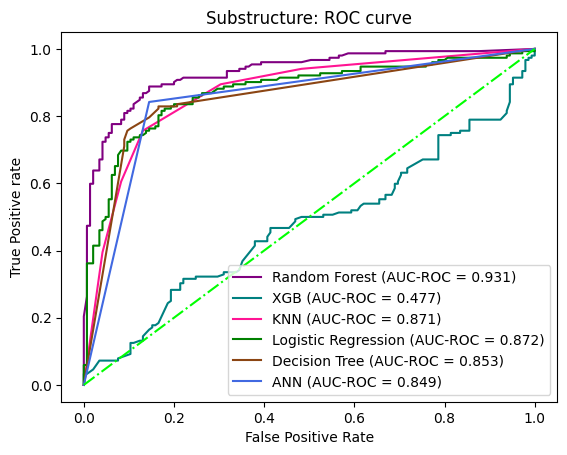

In [58]:
import matplotlib.pyplot as plt


# plot roc curves

plt.plot(rfrf_fpr, rfrf_tpr,  label='Random Forest (AUC-ROC = %0.3f)' % rfrf_auc, color='purple')
plt.plot(rfxgb_fpr, rfxgb_tpr,  label='XGB (AUC-ROC = %0.3f)' % rfxgb_auc, color='teal')
plt.plot(rfknn_fpr, rfknn_tpr, label='KNN (AUC-ROC = %0.3f)' % rfknn_auc, color='deeppink')
plt.plot(rflr_fpr, rflr_tpr, label='Logistic Regression (AUC-ROC = %0.3f)' % rflr_auc, color='green')
plt.plot(rfdt_fpr, rfdt_tpr, label='Decision Tree (AUC-ROC = %0.3f)' % rfdt_auc, color='saddlebrown')
plt.plot(rfann_fpr, rfann_tpr, label='ANN (AUC-ROC = %0.3f)' % rfann_auc, color='royalblue')


plt.plot(p_fpr, p_tpr, linestyle='-.', color='lime')

# title
plt.title('Substructure: ROC curve')
# x label
plt.xlabel('False Positive Rate')
# y label
plt.ylabel('True Positive rate')

plt.legend(loc='best')
plt.savefig('Substructure: ROC curve',dpi=300)
plt.show();